In [1]:
!pip install tensorflow keras matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir='/content/drive/MyDrive/chest_xray'

train_dir='/content/drive/MyDrive/chest_xray/train'
val_dir='/content/drive/MyDrive/chest_xray/val'
test_dir='/content/drive/MyDrive/chest_xray/test'

IMG_HEIGHT=150
IMG_WIDTH=150
BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=[IMG_HEIGHT,IMG_WIDTH],
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten,Dense,Dropout

model=Sequential((
    Conv2D(32,(3,3),activation='relu',input_shape=(IMG_HEIGHT,IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/chest_xray/val',
    target_size=[IMG_HEIGHT,IMG_WIDTH],
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
epochs=10
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Found 16 images belonging to 2 classes.
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8660 - loss: 0.3060

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.8660 - loss: 0.3059 - val_accuracy: 0.6875 - val_loss: 0.8053
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.8940 - loss: 0.2537 - val_accuracy: 0.6875 - val_loss: 1.2153
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9094 - loss: 0.2240 - val_accuracy: 0.8750 - val_loss: 0.5327
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9199 - loss: 0.2029 - val_accuracy: 0.7500 - val_loss: 0.8711
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.9284 - loss: 0.1849 - val_accuracy: 0.6250 - val_loss: 0.8143
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9420 - loss: 0.1650 - val_accuracy: 0.6250 - val_loss: 0.9468
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9374 - loss: 0.1671 - val_accuracy: 0.6875 - val_loss: 0.7215
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9378 - loss: 0.1620 - val_accuracy: 0.562

Found 624 images belonging to 2 classes.
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 760ms/step - accuracy: 0.8782 - loss: 0.4316
Test accuracy: 88.49%


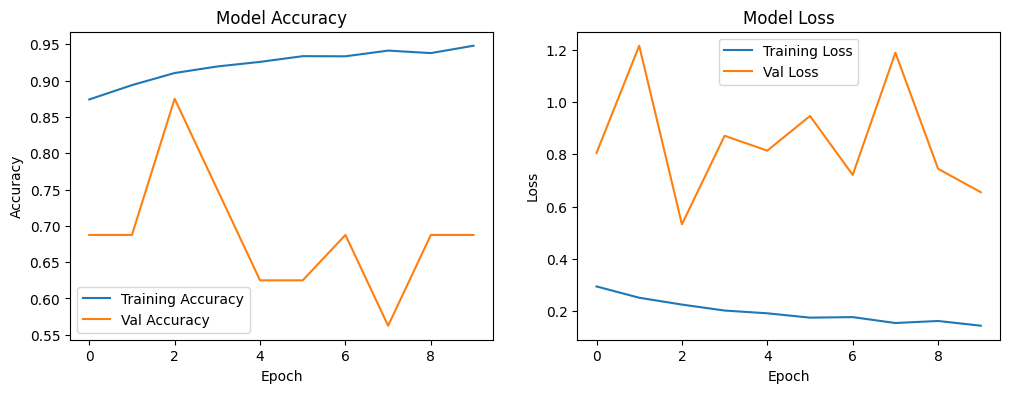

In [22]:
import matplotlib.pyplot as plt

test_generator=test_datagen.flow_from_directory(
    test_dir,
    target_size=[IMG_HEIGHT,IMG_WIDTH],
    batch_size=BATCH_SIZE,
    class_mode='binary',
)

test_loss, test_acc=model.evaluate(test_generator, steps=test_generator.samples//BATCH_SIZE)
print(f"Test accuracy: {test_acc*100:.2f}%")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

y_pred=model.predict(test_generator, steps=test_generator.samples//BATCH_SIZE+1)
y_pred=np.where(y_pred>0.5,1,0)

y_true=test_generator.classes

print("Confusion Matrix")
print(confusion_matrix(y_true,y_pred[:len(y_true)]))

print("Classification Report")
print(classification_report(y_true,y_pred[:len(y_true)],target_names=['Normal','Pneumonia']))


20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 704ms/step
Confusion Matrix
[[ 62 172]
 [111 279]]
Classification Report
              precision    recall  f1-score   support

      Normal       0.36      0.26      0.30       234
   Pneumonia       0.62      0.72      0.66       390

    accuracy                           0.55       624
   macro avg       0.49      0.49      0.48       624
weighted avg       0.52      0.55      0.53       624

